In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Add src directory to system path
sys.path.append("../src")
from load_geo import load_dataset

# Load expression matrix (X) and disease group labels (y)
data_path = "../data/GSE18732_series_matrix.txt"
X, y = load_dataset(data_path)

print(f"Loaded {X.shape[0]} genes for {X.shape[1]} samples.")

Loaded 25770 genes for 118 samples.


In [2]:
# Check expression stats and missing values
print("=== EXPRESSION VALUE STATS ===")
print(f"Minimum Value: {X.values.min():.2f}")
print(f"Maximum Value: {X.values.max():.2f}")
print(f"Median Value:  {np.median(X.values):.2f}")
print(f"Mean Value:    {X.values.mean():.2f}")
print("------------------------------")
print(f"Total Missing (NaN) Values: {X.isnull().sum().sum()}")

=== EXPRESSION VALUE STATS ===
Minimum Value: 0.01
Maximum Value: 159586.03
Median Value:  294.24
Mean Value:    1174.97
------------------------------
Total Missing (NaN) Values: 0


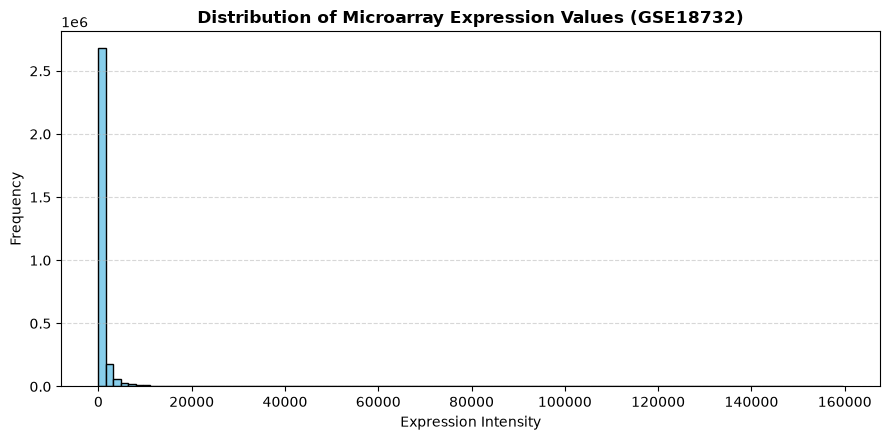

In [3]:
plt.figure(figsize=(9, 4.5))
plt.hist(X.values.flatten(), bins=100, color="skyblue", edgecolor="black")
plt.title("Distribution of Microarray Expression Values (GSE18732)", fontsize=12, fontweight="bold")
plt.xlabel("Expression Intensity")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [4]:
# Calculate average expression per probe across all patients
mean_expr = X.mean(axis=1).sort_values(ascending=False)

print("=== TOP 10 HIGHEST EXPRESSED PROBES ===")
print(mean_expr.head(10))

=== TOP 10 HIGHEST EXPRESSED PROBES ===
ID_REF
ENST00000228841_at    73420.447113
ENST00000361739_at    71973.280656
ENST00000352451_at    71958.943030
ENST00000341685_at    71958.943030
ENST00000379794_at    70701.143944
ENST00000342787_at    70256.839288
ENST00000366683_at    69749.701722
ENST00000366684_at    69749.701722
ENST00000308794_at    69749.701722
ENST00000366682_at    69749.701722
dtype: float64


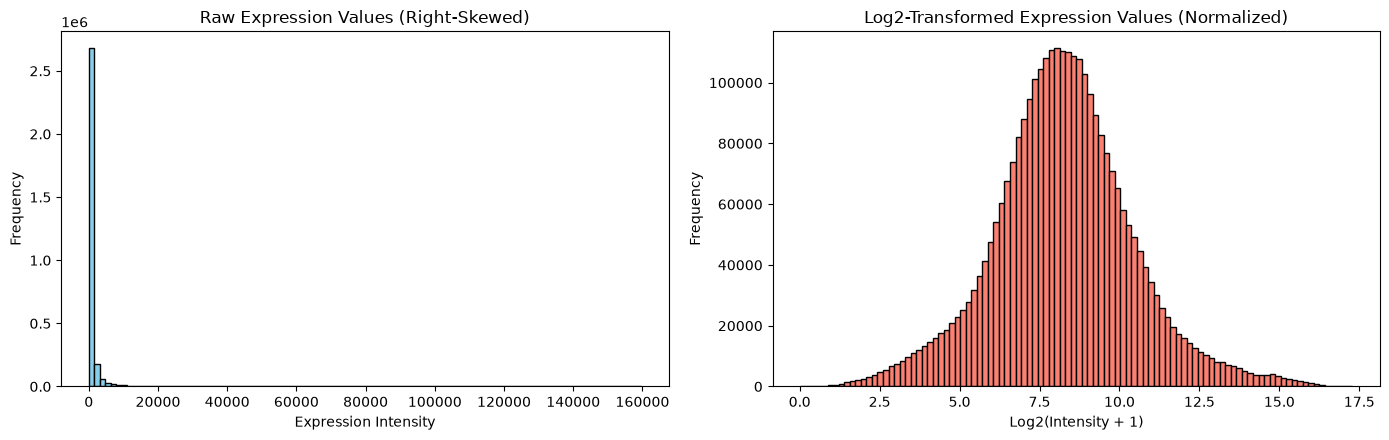

In [5]:
# Apply log2 transformation (adding 1 to prevent log(0) errors)
X_log2 = np.log2(X + 1)

# Plot Raw vs Log2 side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(X.values.flatten(), bins=100, color="skyblue", edgecolor="black")
axes[0].set_title("Raw Expression Values (Right-Skewed)")
axes[0].set_xlabel("Expression Intensity")
axes[0].set_ylabel("Frequency")

axes[1].hist(X_log2.values.flatten(), bins=100, color="salmon", edgecolor="black")
axes[1].set_title("Log2-Transformed Expression Values (Normalized)")
axes[1].set_xlabel("Log2(Intensity + 1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [6]:
# Check for Affymetrix control spike-in probes (starting with 'AFFX-')
affx_probes = [gene for gene in X.index if gene.startswith("AFFX-")]
num_affx = len(affx_probes)

print(f"=== CONTROL PROBES CHECK ===")
print(f"Total AFFX Control Probes: {num_affx} (out of {len(X)} total probes)")
print(f"Percentage of Control Probes: {(num_affx / len(X)) * 100:.2f}%")
print("\nFirst 5 Control Probes:")
print(affx_probes[:5])

=== CONTROL PROBES CHECK ===
Total AFFX Control Probes: 60 (out of 25770 total probes)
Percentage of Control Probes: 0.23%

First 5 Control Probes:
['AFFX-BioB-3_at', 'AFFX-BioB-5_at', 'AFFX-BioB-M_at', 'AFFX-BioC-3_at', 'AFFX-BioC-5_at']


In [9]:
# Calculate average expression per probe across all 118 samples
mean_expr = X.mean(axis=1).sort_values(ascending=False)

print("=== TOP EXPRESSED PROBES ANALYSIS ===")
print(mean_expr.head(10))

# Compute exact count of duplicated mean values in top 20
top_20 = mean_expr.head(20)
duplicated_mask = top_20.duplicated(keep=False)
dup_count = duplicated_mask.sum()

print("\n=== DUPLICATED MEANS EVIDENCE ===")
print(f"Number of top 20 probes sharing identical mean expression: {dup_count}")
print("\nProbes with identical means:")
print(top_20[duplicated_mask])

=== TOP EXPRESSED PROBES ANALYSIS ===
ID_REF
ENST00000228841_at    73420.447113
ENST00000361739_at    71973.280656
ENST00000352451_at    71958.943030
ENST00000341685_at    71958.943030
ENST00000379794_at    70701.143944
ENST00000342787_at    70256.839288
ENST00000366683_at    69749.701722
ENST00000366684_at    69749.701722
ENST00000308794_at    69749.701722
ENST00000366682_at    69749.701722
dtype: float64

=== DUPLICATED MEANS EVIDENCE ===
Number of top 20 probes sharing identical mean expression: 6

Probes with identical means:
ID_REF
ENST00000352451_at    71958.943030
ENST00000341685_at    71958.943030
ENST00000366683_at    69749.701722
ENST00000366684_at    69749.701722
ENST00000308794_at    69749.701722
ENST00000366682_at    69749.701722
dtype: float64


## Key Exploratory Findings (GSE18732)

- **Dataset Dimensions & Completeness**:
  - **Probes**: 25,770
  - **Patients**: 118 (`NGT`: 60, `DM`: 46, `IGT`: 12)
  - **Missing Values**: 0 (Complete dataset)

- **Metadata Alignment Verification**:
  - Manually verified positional column alignment between `!Sample_geo_accession` and `!Sample_characteristics_ch1` for `GSM465274` (IGT, value 2), `GSM465275` (NGT, value 1), and `GSM465276` (NGT, value 1). Tab-delimited sample ordering strictly matches label ordering.

- **Expression Profile & Normalization**:
  - Raw values range from **0.01 to 159,586.03** with a **median of 294.24** and a **mean of 1,174.97**.
  - Highly right-skewed distribution characteristic of raw microarray intensity data.
  - Applying a $\log_2(X + 1)$ transformation rescales intensities into a symmetrical, bell-like curve ranging from **0 to ~17.5**, essential for model training.

- **Control Probe Identification**:
  - Identified **60 AFFX control probes** (0.23% of total features). These are technical spike-in controls that will be removed during cleaning.

- **Transcript-to-Gene Mapping (ENST Multi-Mapping)**:
  - Computed hard evidence showing **6 probes in the top 20** sharing identical mean expression values: 
    - 2 probes (`ENST00000352451_at`, `ENST00000341685_at`) at **71,958.943030**.
    - 4 probes (`ENST00000366683_at`, `ENST00000366684_at`, `ENST00000308794_at`, `ENST00000366682_at`) at **69,749.701722**.
  - This confirms duplicate transcript measurements for identical gene targets, reinforcing the necessity of gene-level aggregation during data cleaning.